[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Winfredy/SadTalker/blob/main/quick_demo.ipynb)

### SadTalker：Learning Realistic 3D Motion Coefficients for Stylized Audio-Driven Single Image Talking Face Animation

[arxiv](https://arxiv.org/abs/2211.12194) | [project](https://sadtalker.github.io) | [Github](https://github.com/Winfredy/SadTalker)

Wenxuan Zhang, Xiaodong Cun, Xuan Wang, Yong Zhang, Xi Shen, Yu Guo, Ying Shan, Fei Wang.

Xi'an Jiaotong University, Tencent AI Lab, Ant Group

CVPR 2023

TL;DR: A realistic and stylized talking head video generation method from a single image and audio


Installation (around 5 mins)

In [2]:
### make sure that CUDA is available in Edit -> Nootbook settings -> GPU
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

NVIDIA L4, 23034 MiB, 22564 MiB


In [3]:
!update-alternatives --install /usr/local/bin/python3 python3 /usr/bin/python3.8 2
!update-alternatives --install /usr/local/bin/python3 python3 /usr/bin/python3.9 1
!sudo apt install python3.8

!sudo apt-get install python3.8-distutils

!python --version

!apt-get update

!apt install software-properties-common

!sudo dpkg --remove --force-remove-reinstreq python3-pip python3-setuptools python3-wheel

!apt-get install python3-pip

print('Git clone project and install requirements...')
!git clone https://github.com/Winfredy/SadTalker &> /dev/null
%cd SadTalker
!export PYTHONPATH=/content/SadTalker:$PYTHONPATH
!python3.8 -m pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu113
!apt update
!apt install ffmpeg &> /dev/null
!python3.8 -m pip install -r requirements.txt

update-alternatives: renaming python3 link from /usr/bin/python3 to /usr/local/bin/python3
update-alternatives: error: alternative path /usr/bin/python3.9 doesn't exist
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3.8 is already the newest version (3.8.20-1+jammy1).
0 upgraded, 0 newly installed, 0 to remove and 58 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3.8-distutils is already the newest version (3.8.20-1+jammy1).
0 upgraded, 0 newly installed, 0 to remove and 58 not upgraded.
Python 3.12.13
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://

Download models (1 mins)

In [4]:
print('Download pre-trained models...')
!rm -rf checkpoints
!bash scripts/download_models.sh

Download pre-trained models...
--2026-06-02 07:02:28--  https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2-rc/mapping_00109-model.pth.tar
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/569518584/ccc415aa-c6f4-47ee-8250-b10bf440ba62?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-02T07%3A41%3A34Z&rscd=attachment%3B+filename%3Dmapping_00109-model.pth.tar&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-02T06%3A40%3A39Z&ske=2026-06-02T07%3A41%3A34Z&sks=b&skv=2018-11-09&sig=mDfDDq8zfYQUaHqY7lclNAcEA%2Bz0p011ct2hTq%2FR75o%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MDM4NzM0OCwibmJ

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


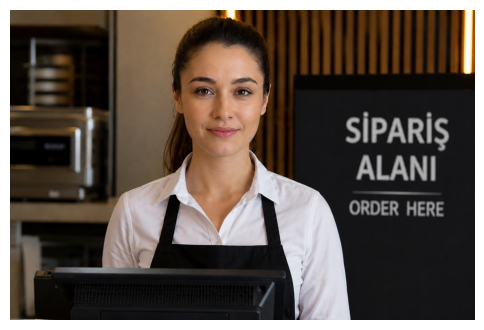

Görüntü: /content/drive/MyDrive/face.png
Ses: /content/drive/MyDrive/karsilama_hizli4.wav


In [45]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt

IMAGE_PATH = "/content/drive/MyDrive/face.png"
AUDIO_PATH = "/content/drive/MyDrive/karsilama_hizli4.wav"

# Resmi göster
img = plt.imread(IMAGE_PATH)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Görüntü:", IMAGE_PATH)
print("Ses:", AUDIO_PATH)

In [46]:
import os

print(os.path.exists("/content/drive/MyDrive/karsilama_hizli4.wav"))

True


In [47]:
source_image = "/content/drive/MyDrive/face.png"
driven_audio = "/content/drive/MyDrive/karsilama_hizli4.wav"

In [12]:
!sed -i 's/np.float/float/g' /content/SadTalker/src/face3d/util/my_awing_arch.py

In [13]:
!grep -n "astype" /content/SadTalker/src/face3d/util/my_awing_arch.py

18:    preds = preds.astype(float, copy=False)


In [15]:
!grep -n "trans_params" /content/SadTalker/src/face3d/util/preprocess.py

100:    trans_params = np.array([w0, h0, s, t[0], t[1]])
102:    return trans_params, img_new, lm_new, mask_new


In [21]:
file_path = "/content/SadTalker/src/face3d/util/preprocess.py"

with open(file_path, "r", encoding="utf-8") as f:
    content = f.read()

old = "trans_params = np.array([w0, h0, s, t[0], t[1]])"

new = """trans_params = np.array([
    float(w0),
    float(h0),
    float(s),
    float(np.squeeze(t)[0]),
    float(np.squeeze(t)[1])
])"""

content = content.replace(old, new)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(content)

print("Patch uygulandı.")

Patch uygulandı.


In [16]:
!sed -n '90,110p' /content/SadTalker/src/face3d/util/preprocess.py

        lm5p = extract_5p(lm)
    else:
        lm5p = lm

    # calculate translation and scale factors using 5 facial landmarks and standard landmarks of a 3D face
    t, s = POS(lm5p.transpose(), lm3D.transpose())
    s = rescale_factor/s

    # processing the image
    img_new, lm_new, mask_new = resize_n_crop_img(img, lm, t, s, target_size=target_size, mask=mask)
    trans_params = np.array([w0, h0, s, t[0], t[1]])

    return trans_params, img_new, lm_new, mask_new


In [48]:
!python inference.py \
  --source_image "/content/drive/MyDrive/face.png" \
  --driven_audio "/content/drive/MyDrive/karsilama_hizli4.wav" \
  --result_dir results \
  --size 512 \
  --preprocess full \
  --still \
  --enhancer gfpgan

using safetensor as default
3DMM Extraction for source image
landmark Det:: 100% 1/1 [00:00<00:00,  6.76it/s]
3DMM Extraction In Video:: 100% 1/1 [00:00<00:00, 11.92it/s]
mel:: 100% 105/105 [00:00<00:00, 44444.64it/s]
audio2exp:: 100% 11/11 [00:00<00:00, 112.51it/s]
Face Renderer:: 100% 53/53 [01:12<00:00,  1.36s/it]
The generated video is named results/2026_06_02_07.50.56/face##karsilama_hizli4.mp4
OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'
seamlessClone:: 100% 105/105 [00:09<00:00, 11.43it/s]
The generated video is named results/2026_06_02_07.50.56/face##karsilama_hizli4_full.mp4
face enhancer....
Face Enhancer:: 100% 105/105 [01:06<00:00,  1.59it/s]
The generated video is named results/2026_06_02_07.50.56/face##karsilama_hizli4_enhanced.mp4
The generated video is named: results/2026_06_02_07.50.56.mp4


In [14]:
!pip install \
numpy==1.26.4 \
face_alignment==1.3.5 \
imageio \
imageio-ffmpeg \
librosa==0.10.1 \
resampy==0.4.3 \
scipy==1.11.4 \
kornia==0.7.1 \
yacs==0.1.8 \
joblib==1.4.2 \
scikit-image==0.22.0 \
basicsr==1.4.2 \
facexlib==0.3.0 \
gfpgan \
av \
safetensors

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached face_alignment-1.3.5-py2.py3-none-any.whl.metadata (6.6 kB)
  Using cached librosa-0.10.1-py3-none-any.whl.metadata (8.3 kB)
  Using cached resampy-0.4.3-py3-none-any.whl.metadata (3.0 kB)
  Using cached scipy-1.11.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached kornia-0.7.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_image-0.22.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached basicsr-1.4.2.tar.gz (172 kB)
  Preparing metadata (setup.py) ... done
  Using cached facexlib-0.3.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached gfpgan-1.3.8-py3-none-any.whl.metadata (12 kB)
  Using cached av-17.0.1-cp311-abi3-manylinux_2_28_x86_64.whl.metadata 

Animation

In [8]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [9]:
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g' \
/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

In [10]:
!grep "rgb_to_grayscale" /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

from torchvision.transforms.functional import rgb_to_grayscale
        img_gray = rgb_to_grayscale(img, num_output_channels=1)


In [ ]:
# visualize code from makeittalk
from IPython.display import HTML
from base64 import b64encode
import os, sys

# get the last from results

results = sorted(os.listdir('./results/'))

mp4_name = glob.glob('./results/*.mp4')[0]

mp4 = open('{}'.format(mp4_name),'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

print('Display animation: {}'.format(mp4_name), file=sys.stderr)
display(HTML("""
  <video width=256 controls>
        <source src="%s" type="video/mp4">
  </video>
  """ % data_url))
